In [11]:
from pathlib import Path
import sys
import warnings
import os
from joblib import parallel_backend

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

REPO_ROOT = Path(r'C:\Users\Rosa Daneshmandnia\predicting-global-conflict')
if str(REPO_ROOT / 'forecast_model') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'forecast_model'))

RANDOM_STATE = 42

In [4]:
model_data = pd.read_csv(r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\data\processed\model_data.csv")

model_data = model_data.set_index(['matched_admin1_id', 'month_year'])

model_data = model_data.sort_index()

print(f'Loaded: {model_data.shape[0]:,} rows x {model_data.shape[1]} cols')
model_data.info()
model_data.describe()

Loaded: 278,820 rows x 100 cols
<class 'pandas.DataFrame'>
MultiIndex: 278820 entries, ('ABW - Aruba', '2018-01') to (nan, '2025-06')
Data columns (total 100 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Battles (t-1)                                275633 non-null  float64
 1   Explosions/Remote violence (t-1)             275633 non-null  float64
 2   Protests (t-1)                               275633 non-null  float64
 3   Riots (t-1)                                  275633 non-null  float64
 4   Strategic developments (t-1)                 275633 non-null  float64
 5   Violence against civilians (t-1)             275633 non-null  float64
 6   Excessive force against protesters (t-1)     275633 non-null  float64
 7   Agreement (t-1)                              275633 non-null  float64
 8   Explosions/Remote violence_neighbours (t-1)  275633 non-null  float64
 9   St

,Battles (t-1),Explosions/Remote violence (t-1),Protests (t-1),Riots (t-1),Strategic developments (t-1),Violence against civilians (t-1),Excessive force against protesters (t-1),Agreement (t-1),Explosions/Remote violence_neighbours (t-1),Strategic developments_neighbours (t-1),...,risk_military_coup,risk_natural_disaster,risk_political_assassination,risk_contested_election (t-1),risk_crop_failure (t-1),risk_economic_concern (t-1),risk_ethnic_tension (t-1),risk_military_coup (t-1),risk_natural_disaster (t-1),risk_political_assassination (t-1)
count,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,...,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000
mean,1.238741,1.409740,3.471569,0.481844,0.565821,0.856490,0.013707,0.009556,6.946316,2.895836,...,0.069260,0.350133,0.105297,0.099577,0.380432,0.247174,0.138634,0.068273,0.342364,0.099778
std,13.849694,23.869244,13.955840,5.851017,3.813787,4.079164,0.431490,0.165491,72.337224,12.018981,...,0.333235,1.146762,0.844635,0.489615,1.042766,0.675020,0.531955,0.331815,1.130166,0.831644
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1664.000000,1773.000000,715.000000,862.000000,286.000000,234.000000,119.000000,29.000000,3961.000000,464.000000,...,16.000000,37.000000,26.000000,12.000000,19.000000,31.000000,23.000000,16.000000,37.000000,26.000000


In [5]:
RAW_TARGETS = [
    'Battles',
    'Explosions/Remote violence',
    'Violence against civilians',
]

DELTA_TARGET_MAP = {
    'Battles': 'delta_battles',
    'Explosions/Remote violence': 'delta_remote_violence',
    'Violence against civilians': 'delta_vac',
}

DELTA_TARGETS = []

for target in RAW_TARGETS:
    lag_col = f'{target} (t-1)'
    delta_col = DELTA_TARGET_MAP[target]

    if lag_col in model_data.columns:
        model_data[delta_col] = model_data[target] - model_data[lag_col]
        DELTA_TARGETS.append(delta_col)

delta_summary = model_data[DELTA_TARGETS].agg(['mean', 'std', 'min', 'max']).T.round(3)
delta_summary['zero_share'] = (model_data[DELTA_TARGETS] == 0).mean().round(3)
delta_summary['negative_share'] = (model_data[DELTA_TARGETS] < 0).mean().round(3)
delta_summary['positive_share'] = (model_data[DELTA_TARGETS] > 0).mean().round(3)

delta_summary

,mean,std,min,max,zero_share,negative_share,positive_share
delta_battles,-0.006,4.142,-582.0,385.0,0.857,0.066,0.065
delta_remote_violence,0.004,7.362,-1004.0,879.0,0.922,0.033,0.033
delta_vac,-0.001,1.988,-149.0,188.0,0.799,0.095,0.094


In [6]:
#same as raw notebook
all_cols = model_data.columns.tolist()

conflict_lag_features = [c for c in all_cols if c.endswith('(t-1)') and c.split(' (t-1)')[0] in [
    'Battles', 'Explosions/Remote violence', 'Protests', 'Riots',
    'Strategic developments', 'Violence against civilians',
    'Excessive force against protesters', 'Agreement'
]]

neighbor_features = [c for c in all_cols if '_neighbours (t-1)' in c]

time_features = [
    c for c in all_cols
    if c == 'linear_month_trend' or c == 'year' or c.startswith('month_') or c.startswith('quarter_')
]

worldbank_lag_features = [c for c in [
    'inflation (t-1)', 'youth_unemployment (t-1)', 'income_inequality (t-1)', 'income_level_code (t-1)'
] if c in all_cols]

religion_features = [c for c in [
    'majority_religion', 'majority_pct', 'minority1_religion', 'minority1_pct',
    'minority2_religion', 'minority2_pct', 'nonreligpct'
] if c in all_cols]

holiday_current_features = [c for c in all_cols if 'holiday_count' in c and '(t-1)' not in c]

holiday_interaction_current = [c for c in [
    'weighted_holidays_majority', 'weighted_holidays_minority1', 'weighted_holidays_minority2',
    'minority_tension_minority1', 'minority_tension_minority2', 'minority_tension_total',
    'total_religious_mobilization'
] if c in all_cols]

wbd_engineered_features = [c for c in [
    'structural_vulnerability', 'inflation_shock', 'shock_vulnerability', 'capacity_adjusted_risk',
    'inflation_change', 'high_inequality_flag', 'inflation_shock_poor',
    'conflict_momentum', 'violence_escalation', 'macro_conflict_pressure'
] if c in all_cols]

risk_features = [c for c in all_cols if c.startswith('risk_')]

excluded_holiday_lags = [c for c in all_cols if 'holiday_count' in c and '(t-1)' in c]

excluded_holiday_interaction_lags = [
    c for c in all_cols
    if '(t-1)' in c and any(k in c for k in ['weighted_holidays', 'minority_tension', 'mobilization'])
]

baseline_feature_cols = list(dict.fromkeys(
    conflict_lag_features
    + neighbor_features
    + time_features
    + worldbank_lag_features
    + religion_features
    + holiday_current_features
    + holiday_interaction_current
    + wbd_engineered_features
    + risk_features
))

len(baseline_feature_cols)

80

In [7]:
def split_region_data(region_data, test_horizon=6):
    train = region_data.iloc[:-test_horizon]
    test = region_data.iloc[-test_horizon:]
    return train, test


def encode_categoricals(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    cat_cols = X_train.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    for col in cat_cols:
        le = LabelEncoder()

        X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
        X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

        X_train[col] = le.fit_transform(X_train[col])

        known = set(le.classes_)
        X_test[col] = X_test[col].map(
            lambda x: le.transform([x])[0] if x in known else -1
        )

    return X_train, X_test


def prepare_rf_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    num_bool_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
    X_train[num_bool_cols] = X_train[num_bool_cols].fillna(0)
    X_test[num_bool_cols] = X_test[num_bool_cols].fillna(0)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


def prepare_catboost_native_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    cat_cols = X_train.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    for col in cat_cols:
        X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
        X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

    return X_train, X_test, cat_cols


def prepare_catboost_encoded_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


CATBOOST_MODE = "native"  # or "encoded"


def prepare_catboost_inputs(train_df, test_df, feature_cols, mode=CATBOOST_MODE):
    if mode == "native":
        return prepare_catboost_native_inputs(train_df, test_df, feature_cols)
    elif mode == "encoded":
        X_train, X_test = prepare_catboost_encoded_inputs(train_df, test_df, feature_cols)
        return X_train, X_test, None
    else:
        raise ValueError("mode must be 'native' or 'encoded'")


def prepare_lgbm_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [8]:
MODELS = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    'LightGBM_Regression': LGBMRegressor(
        objective='regression',
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=4,
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
    ),
}

MODELS

{'RandomForest': RandomForestRegressor(n_estimators=300, n_jobs=1, random_state=42),
 'LightGBM_Regression': LGBMRegressor(learning_rate=0.05, max_depth=4, n_estimators=500,
               objective='regression', random_state=42, verbose=-1),
 'CatBoost': CatBoostRegressor(depth=4, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0),
 'HistGradientBoosting': HistGradientBoostingRegressor(learning_rate=0.05, max_depth=4, max_iter=500,
                               random_state=42)}

In [9]:
all_regions = model_data.index.get_level_values('matched_admin1_id').unique()

VALID_REGIONS = []
skipped_too_short = []
skipped_all_zero = []

for region in all_regions:
    region_data = model_data.loc[region].sort_index()

    if len(region_data) < 12:
        skipped_too_short.append(region)
        continue

    train_data, test_data = split_region_data(region_data)

    if train_data[DELTA_TARGETS].nunique().max() <= 1:
        skipped_all_zero.append(region)
        continue

    VALID_REGIONS.append(region)

print(f"Valid regions: {len(VALID_REGIONS)}")
print(f"Skipped (<12 months): {len(skipped_too_short)}")
print(f"Skipped (no variation in delta targets): {len(skipped_all_zero)}")

VALID_REGIONS[:10]

Valid regions: 2205
Skipped (<12 months): 0
Skipped (no variation in delta targets): 893


['AFG - Badakhshan',
 'AFG - Badghis',
 'AFG - Baghlan',
 'AFG - Balkh',
 'AFG - Bamyan',
 'AFG - Daykundi',
 'AFG - Farah',
 'AFG - Faryab',
 'AFG - Ghazni',
 'AFG - Ghor']

In [12]:
RUN_REGIONS = VALID_REGIONS
RUN_TARGETS = DELTA_TARGETS

results = []
feature_importances = {}

with parallel_backend("sequential"):
    for region in RUN_REGIONS:
        region_data = model_data.loc[region].sort_index()
        train_data, test_data = split_region_data(region_data)
        weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None
    
        for target in RUN_TARGETS:
            train_pair = train_data[baseline_feature_cols + [target]].copy()
            test_pair = test_data[baseline_feature_cols + [target]].copy()
    
            train_pair = train_pair[train_pair[target].notna()]
            test_pair = test_pair[test_pair[target].notna()]
    
            if len(train_pair) == 0 or len(test_pair) == 0:
                continue
    
            y_train = train_pair[target]
            y_test = test_pair[target]
    
            if y_train.nunique() <= 1:
                continue

            weights = None
            if weights_full is not None:
                weights = weights_full.loc[train_pair.index]
    
            X_train_rf, X_test_rf = prepare_rf_inputs(train_pair, test_pair, baseline_feature_cols)
            X_train_lgbm, X_test_lgbm = prepare_lgbm_inputs(train_pair, test_pair, baseline_feature_cols)
            X_train_hgb, X_test_hgb = prepare_rf_inputs(train_pair, test_pair, baseline_feature_cols)
            X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
                train_pair, test_pair, baseline_feature_cols
            )
    
            model_specs = {
                'RandomForest': RandomForestRegressor(
                    n_estimators=300,
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
                'LightGBM_Regression': LGBMRegressor(
                    objective='regression',
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=4,
                    random_state=RANDOM_STATE,
                    verbose=-1,
                ),
                'CatBoost': CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=4,
                    random_seed=RANDOM_STATE,
                    verbose=0,
                ),
                'HistGradientBoosting': HistGradientBoostingRegressor(
                    max_iter=500,
                    learning_rate=0.05,
                    max_depth=4,
                    random_state=RANDOM_STATE,
                ),
            }

            for model_name, model in model_specs.items():
                try:
                    if model_name == 'RandomForest':
                        X_tr, X_te = X_train_rf, X_test_rf
                        fit_kwargs = {}
                        if weights is not None:
                            fit_kwargs['sample_weight'] = weights.values
    
                    elif model_name == 'LightGBM_Regression':
                        X_tr, X_te = X_train_lgbm, X_test_lgbm
                        fit_kwargs = {}
                        if weights is not None:
                            fit_kwargs['sample_weight'] = weights.values

                    elif model_name == 'HistGradientBoosting':
                        X_tr, X_te = X_train_hgb, X_test_hgb
                        fit_kwargs = {}
    
                    else:
                        X_tr, X_te = X_train_cb, X_test_cb
                        fit_kwargs = {}
                        if cat_cols_cb is not None:
                            fit_kwargs['cat_features'] = cat_cols_cb
                        if weights is not None:
                            fit_kwargs['sample_weight'] = weights.values
    
                    model.fit(X_tr, y_train, **fit_kwargs)
                    y_pred = model.predict(X_te)
    
                    results.append({
                        'region': region,
                        'target': target,
                        'model': model_name,
                        'mae': mean_absolute_error(y_test, y_pred),
                        'rmse': rmse(y_test, y_pred),
                        'mean_actual': y_test.mean(),
                        'mean_pred': float(np.mean(y_pred)),
                    })
    
                    if hasattr(model, 'feature_importances_'):
                        feature_importances[(model_name, region, target)] = pd.Series(
                            model.feature_importances_,
                            index=baseline_feature_cols,
                        )
    
                except Exception as exc:
                    print(f'ERROR | {model_name} | {region} | {target}: {exc}')

results_df = pd.DataFrame(results)
print(f"Rows collected: {len(results_df)}")
results_df

Rows collected: 17356


,region,target,model,mae,rmse,mean_actual,mean_pred
0,AFG - Badakhshan,delta_battles,RandomForest,0.860000,1.062670,0.333333,0.413333
1,AFG - Badakhshan,delta_battles,LightGBM_Regression,1.664953,1.908383,0.333333,-1.331620
2,AFG - Badakhshan,delta_battles,CatBoost,0.909597,1.150778,0.333333,0.320109
3,AFG - Badakhshan,delta_battles,HistGradientBoosting,1.617119,1.962698,0.333333,-1.283786
4,AFG - Badakhshan,delta_remote_violence,RandomForest,0.390556,0.517084,0.000000,0.385000
...,...,...,...,...,...,...,...
17351,ZWE - Midlands,delta_battles,HistGradientBoosting,0.078533,0.102733,0.000000,-0.047867
17352,ZWE - Midlands,delta_vac,RandomForest,0.075000,0.122769,0.000000,0.073889
17353,ZWE - Midlands,delta_vac,LightGBM_Regression,0.106195,0.186046,0.000000,0.100057
17354,ZWE - Midlands,delta_vac,CatBoost,0.070082,0.118408,0.000000,0.057243


In [13]:
summary = (
    results_df
    .groupby(['model', 'target'])[['mae', 'rmse']]
    .mean()
    .round(3)
    .sort_index()
)

summary

mae   rmse
model                target                             
CatBoost             delta_battles          1.607  2.030
                     delta_remote_violence  3.011  3.634
                     delta_vac              0.886  1.096
HistGradientBoosting delta_battles          1.858  2.294
                     delta_remote_violence  3.235  3.995
                     delta_vac              0.972  1.184
LightGBM_Regression  delta_battles          1.878  2.326
                     delta_remote_violence  3.649  4.380
                     delta_vac              1.036  1.259
RandomForest         delta_battles          1.678  2.088
                     delta_remote_violence  3.104  3.730
                     delta_vac              0.908  1.111

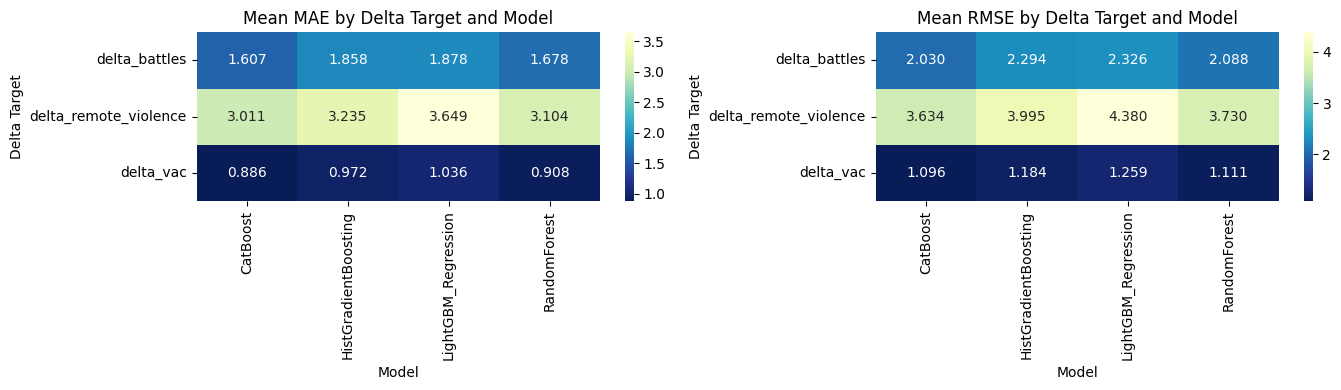

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric in zip(axes, ['mae', 'rmse']):
    heatmap_data = results_df.pivot_table(
        index='target',
        columns='model',
        values=metric,
        aggfunc='mean'
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='YlGnBu_r',
        ax=ax
    )

    ax.set_title(f'Mean {metric.upper()} by Delta Target and Model')
    ax.set_xlabel('Model')
    ax.set_ylabel('Delta Target')

plt.tight_layout()
plt.show()

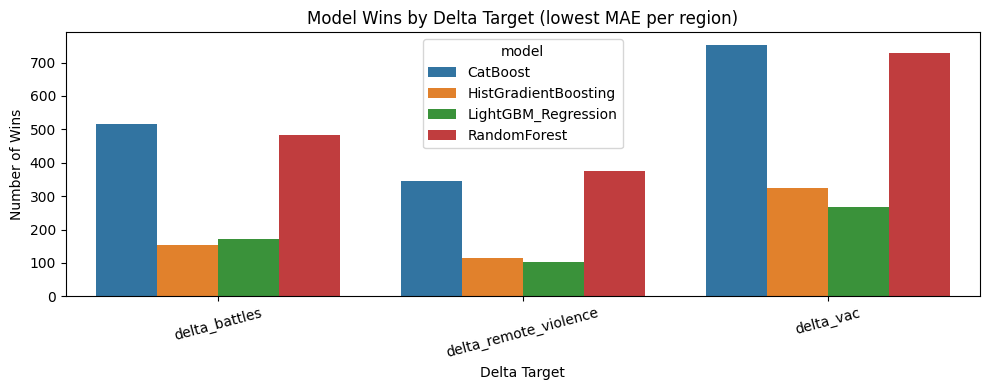

model,CatBoost,HistGradientBoosting,LightGBM_Regression,RandomForest
target,,,,
delta_battles,517,153,171,484
delta_remote_violence,346,115,102,376
delta_vac,753,324,268,730


In [15]:
wins = (
    results_df
    .loc[results_df.groupby(['region', 'target'])['mae'].idxmin()]
    .groupby(['target', 'model'])
    .size()
    .reset_index(name='wins')
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=wins,
    x='target',
    y='wins',
    hue='model'
)

plt.title('Model Wins by Delta Target (lowest MAE per region)')
plt.xlabel('Delta Target')
plt.ylabel('Number of Wins')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

wins.pivot(index='target', columns='model', values='wins').fillna(0).astype(int)

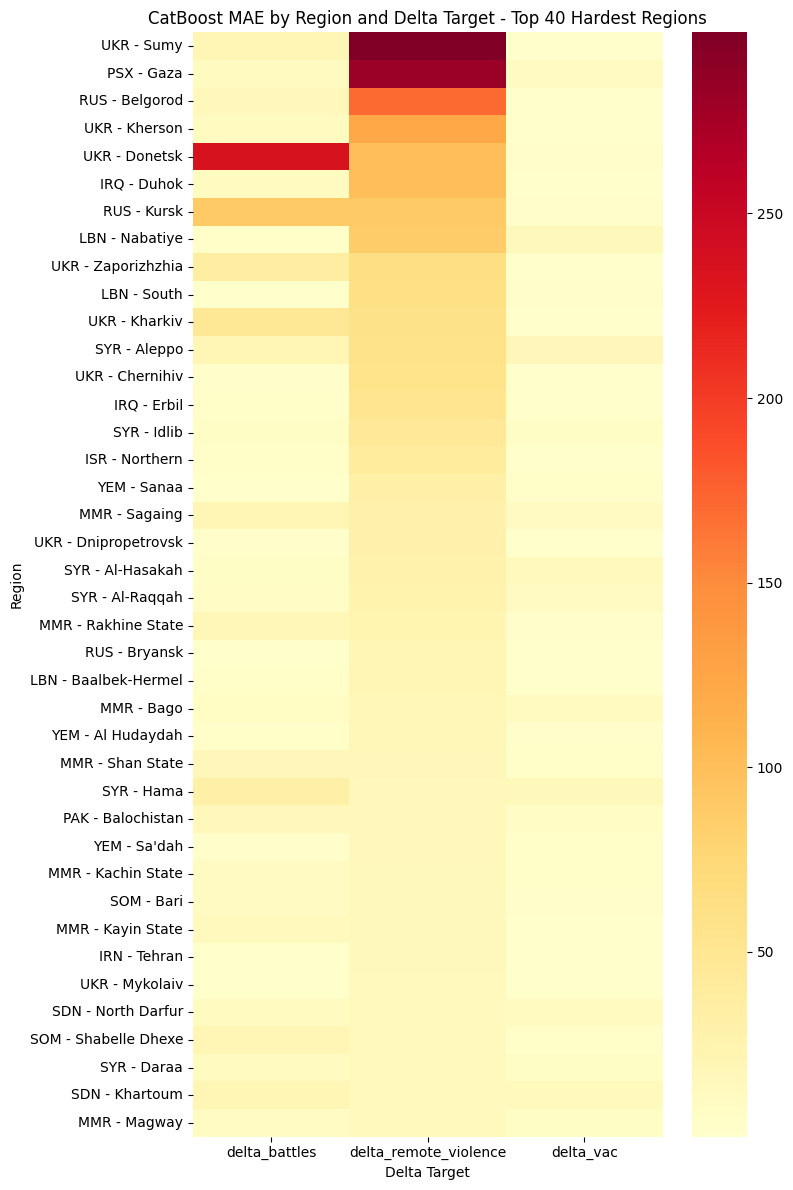

In [16]:
catboost_region_mae = (
    results_df[results_df['model'] == 'CatBoost']
    .pivot_table(
        index='region',
        columns='target',
        values='mae',
        aggfunc='mean'
    )
    .sort_values(by='delta_remote_violence', ascending=False)
    .head(40)
)

plt.figure(figsize=(8, 12))
sns.heatmap(
    catboost_region_mae,
    annot=False,
    cmap='YlOrRd'
)

plt.title('CatBoost MAE by Region and Delta Target - Top 40 Hardest Regions')
plt.xlabel('Delta Target')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

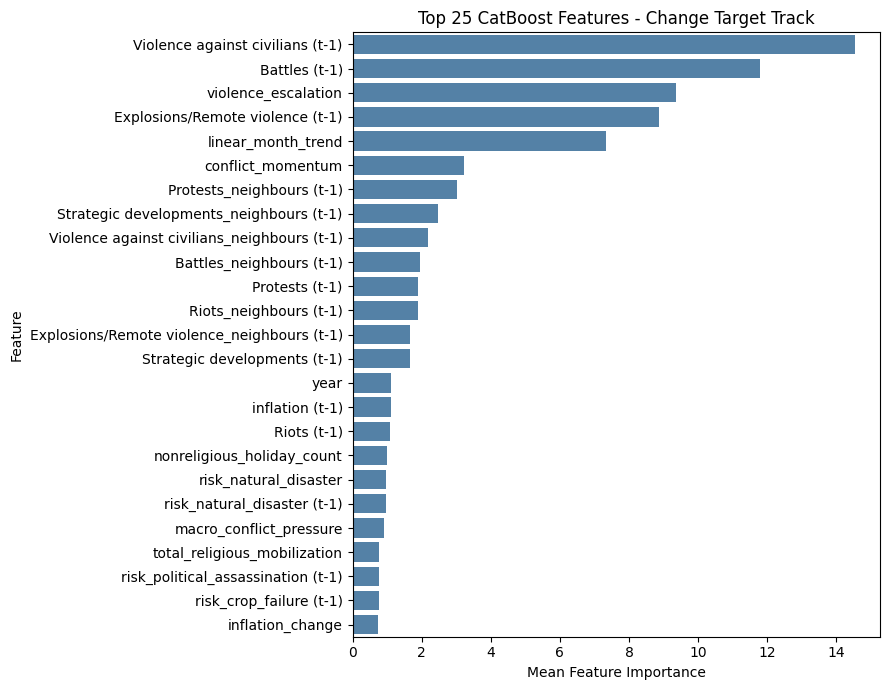

In [17]:
catboost_fi = [
    fi for (model_name, region, target), fi in feature_importances.items()
    if model_name == 'CatBoost'
]

if catboost_fi:
    catboost_fi_mean = (
        pd.concat(catboost_fi, axis=1)
        .mean(axis=1)
        .sort_values(ascending=False)
        .head(25)
    )

    plt.figure(figsize=(9, 7))
    sns.barplot(
        x=catboost_fi_mean.values,
        y=catboost_fi_mean.index,
        color='steelblue'
    )

    plt.title('Top 25 CatBoost Features - Change Target Track')
    plt.xlabel('Mean Feature Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print('No CatBoost feature importances collected.')

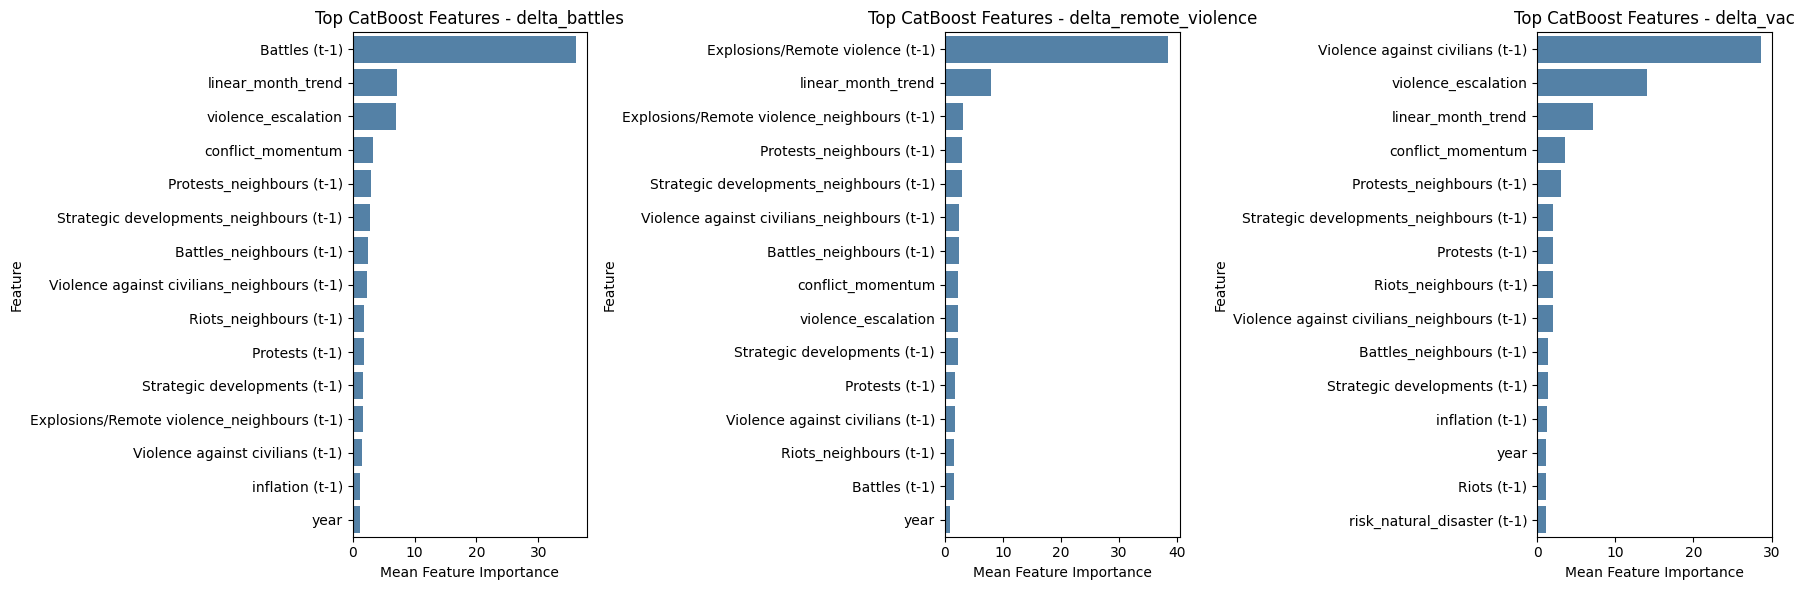

In [19]:
catboost_fi_by_target = {}

for target in DELTA_TARGETS:
    fi_list = [
        fi for (model_name, region, fi_target), fi in feature_importances.items()
        if model_name == 'CatBoost' and fi_target == target
    ]

    if fi_list:
        catboost_fi_by_target[target] = (
            pd.concat(fi_list, axis=1)
            .mean(axis=1)
            .sort_values(ascending=False)
            .head(15)
        )

fig, axes = plt.subplots(
    1,
    len(catboost_fi_by_target),
    figsize=(6 * len(catboost_fi_by_target), 6),
    sharex=False
)

if len(catboost_fi_by_target) == 1:
    axes = [axes]

for ax, (target, fi_values) in zip(axes, catboost_fi_by_target.items()):
    sns.barplot(
        x=fi_values.values,
        y=fi_values.index,
        ax=ax,
        color='steelblue'
    )

    ax.set_title(f'Top CatBoost Features - {target}')
    ax.set_xlabel('Mean Feature Importance')
    ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

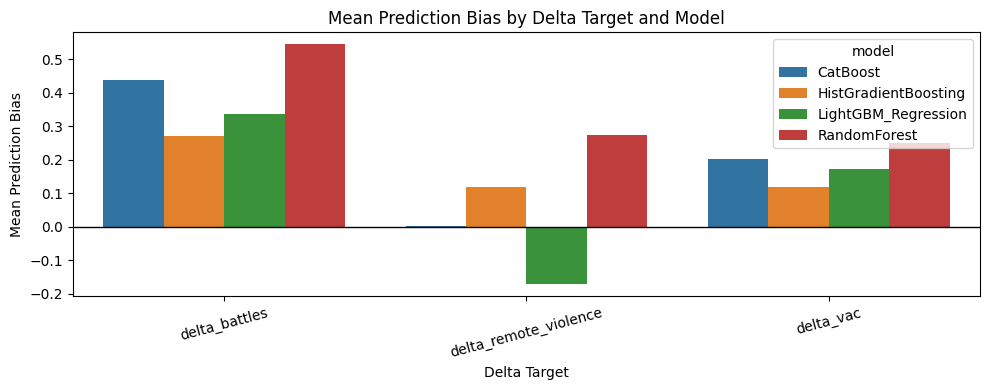

,target,model,bias
0,delta_battles,CatBoost,0.439
1,delta_battles,HistGradientBoosting,0.272
2,delta_battles,LightGBM_Regression,0.338
3,delta_battles,RandomForest,0.545
4,delta_remote_violence,CatBoost,0.003
5,delta_remote_violence,HistGradientBoosting,0.120
6,delta_remote_violence,LightGBM_Regression,-0.172
7,delta_remote_violence,RandomForest,0.274
8,delta_vac,CatBoost,0.202
9,delta_vac,HistGradientBoosting,0.120


In [18]:
bias_summary = results_df.copy()
bias_summary['bias'] = bias_summary['mean_pred'] - bias_summary['mean_actual']

bias_plot = (
    bias_summary
    .groupby(['target', 'model'])['bias']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=bias_plot,
    x='target',
    y='bias',
    hue='model'
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Mean Prediction Bias by Delta Target and Model')
plt.xlabel('Delta Target')
plt.ylabel('Mean Prediction Bias')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

bias_plot.round(3)